# Недообучение и переобучение

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve, cross_validate
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score, f1_score, r2_score
from sklearn.datasets import make_classification, fetch_openml
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Генерация датасета для классификации
X, y = make_classification(n_samples=10000, n_features=500, 
                           n_informative=50, n_repeated=0, 
                           class_sep=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    random_state=3)
print("Размеры:", X_train.shape, X_test.shape)

Размеры: (7500, 500) (2500, 500)


In [3]:
lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
print(f"Training score (accuracy): {lr.score(X_train, y_train):.4f}")
print(f"Test score (accuracy): {lr.score(X_test, y_test):.4f}")

Training score (accuracy): 0.8413
Test score (accuracy): 0.8056


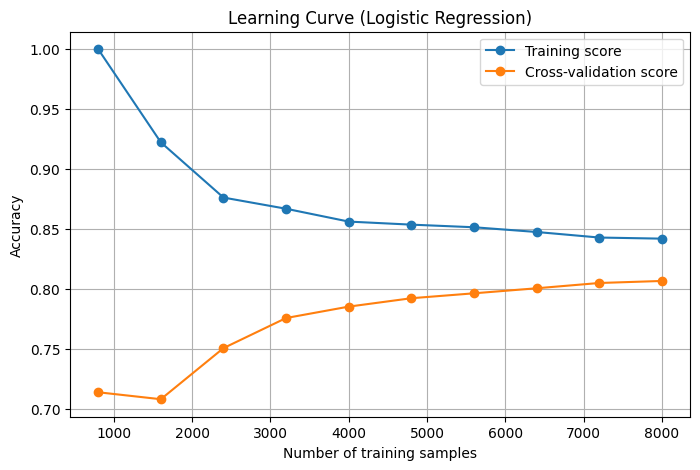

In [4]:
from sklearn.model_selection import learning_curve

train_sizes = np.linspace(0.1, 1.0, 10)
train_sizes_abs, train_scores, test_scores = learning_curve(
    LogisticRegression(max_iter=1000), X, y, 
    train_sizes=train_sizes, cv=5, scoring='accuracy',
    n_jobs=-1)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes_abs, train_mean, 'o-', label='Training score')
plt.plot(train_sizes_abs, test_mean, 'o-', label='Cross-validation score')
plt.xlabel('Number of training samples')
plt.ylabel('Accuracy')
plt.title('Learning Curve (Logistic Regression)')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
ridge_clf = RidgeClassifier(alpha=1000000).fit(X_train, y_train)
print(f"Training score: {ridge_clf.score(X_train, y_train):.4f}")
print(f"Test score: {ridge_clf.score(X_test, y_test):.4f}")

Training score: 0.7724
Test score: 0.7712


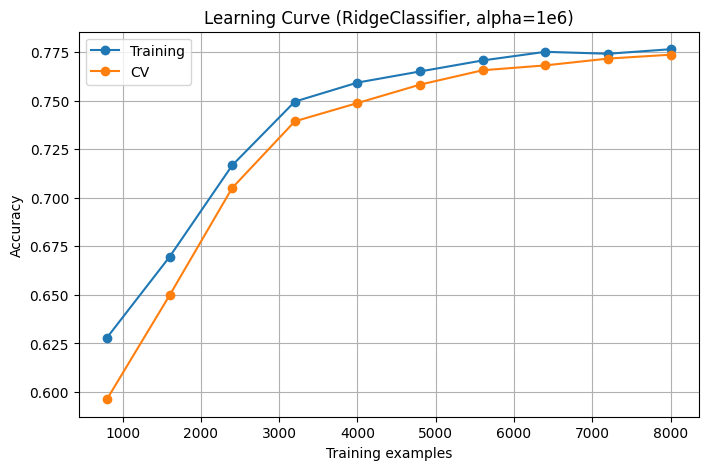

In [6]:
train_sizes_abs, train_scores, test_scores = learning_curve(
    RidgeClassifier(alpha=1000000), X, y, 
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='accuracy', n_jobs=-1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes_abs, np.mean(train_scores, axis=1), 'o-', label='Training')
plt.plot(train_sizes_abs, np.mean(test_scores, axis=1), 'o-', label='CV')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve (RidgeClassifier, alpha=1e6)')
plt.legend()
plt.grid(True)
plt.show()

Training accuracy: 0.8311
Test accuracy: 0.8228


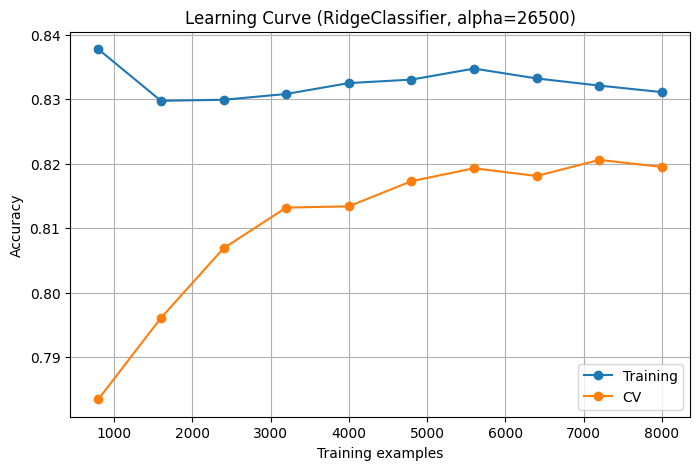

In [7]:
best_ridge = RidgeClassifier(alpha=26500).fit(X_train, y_train)
print(f"Training accuracy: {best_ridge.score(X_train, y_train):.4f}")
print(f"Test accuracy: {best_ridge.score(X_test, y_test):.4f}")

# Кривая обучения для оптимальной модели
train_sizes_abs, train_scores, test_scores = learning_curve(
    RidgeClassifier(alpha=26500), X, y, 
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='accuracy', n_jobs=-1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes_abs, np.mean(train_scores, axis=1), 'o-', label='Training')
plt.plot(train_sizes_abs, np.mean(test_scores, axis=1), 'o-', label='CV')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve (RidgeClassifier, alpha=26500)')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.model_selection import train_test_split

# Загружаем California housing dataset (аналог Boston)
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

# Разделяем данные
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
print("Размеры:", X_train.shape, X_test.shape)

Размеры: (15480, 8) (5160, 8)


In [10]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=0.0001).fit(X_train, y_train)
print(f"Training R^2: {ridge_reg.score(X_train, y_train):.4f}")
print(f"Test R^2: {ridge_reg.score(X_test, y_test):.4f}")

Training R^2: 0.6110
Test R^2: 0.5912


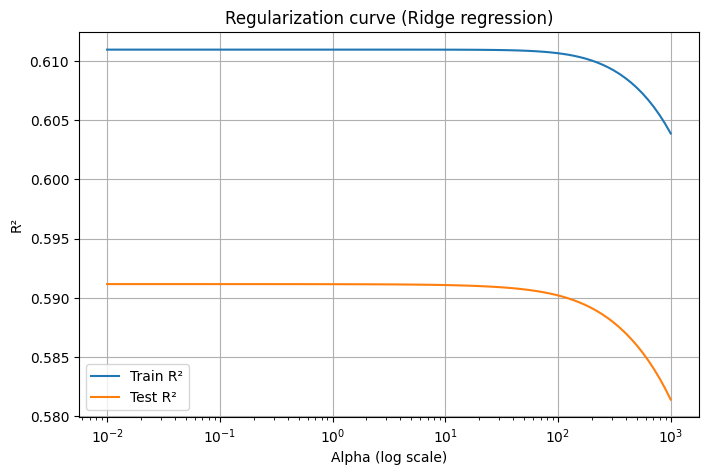

In [11]:
alphas = np.logspace(-2, 3, 100)
train_r2 = []
test_r2 = []

for a in alphas:
    ridge = Ridge(alpha=a).fit(X_train, y_train)
    train_r2.append(ridge.score(X_train, y_train))
    test_r2.append(ridge.score(X_test, y_test))

plt.figure(figsize=(8,5))
plt.semilogx(alphas, train_r2, label='Train R²')
plt.semilogx(alphas, test_r2, label='Test R²')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R²')
plt.title('Regularization curve (Ridge regression)')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
ridge_opt = Ridge(alpha=0.18).fit(X_train, y_train)
print(f"Training R²: {ridge_opt.score(X_train, y_train):.4f}")
print(f"Test R²: {ridge_opt.score(X_test, y_test):.4f}")

Training R²: 0.6110
Test R²: 0.5912


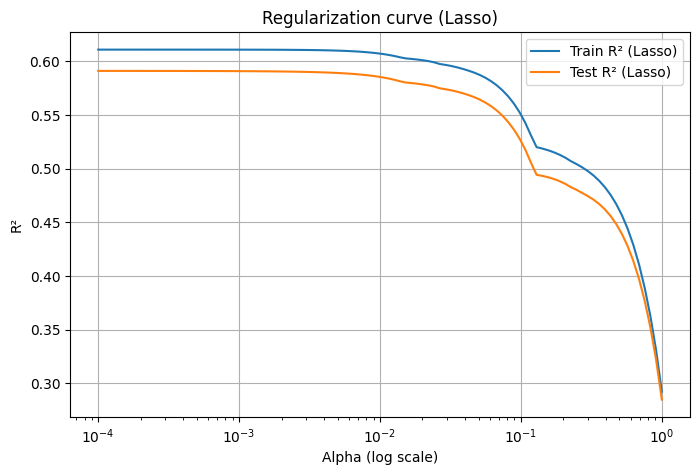

In [13]:
alphas = np.logspace(-4, 0, 100)
train_r2_lasso = []
test_r2_lasso = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000).fit(X_train, y_train)
    train_r2_lasso.append(lasso.score(X_train, y_train))
    test_r2_lasso.append(lasso.score(X_test, y_test))

plt.figure(figsize=(8,5))
plt.semilogx(alphas, train_r2_lasso, label='Train R² (Lasso)')
plt.semilogx(alphas, test_r2_lasso, label='Test R² (Lasso)')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R²')
plt.title('Regularization curve (Lasso)')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
df = pd.read_csv('diabetes.csv', nrows=200)
y = df['Outcome']
X = df.drop('Outcome', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

print(f"Train accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Train F1: {f1_score(y_train, y_train_pred):.4f}")
print(f"Test F1: {f1_score(y_test, y_test_pred):.4f}")

Train accuracy: 1.0000
Test accuracy: 0.5500
Train F1: 1.0000
Test F1: 0.5263


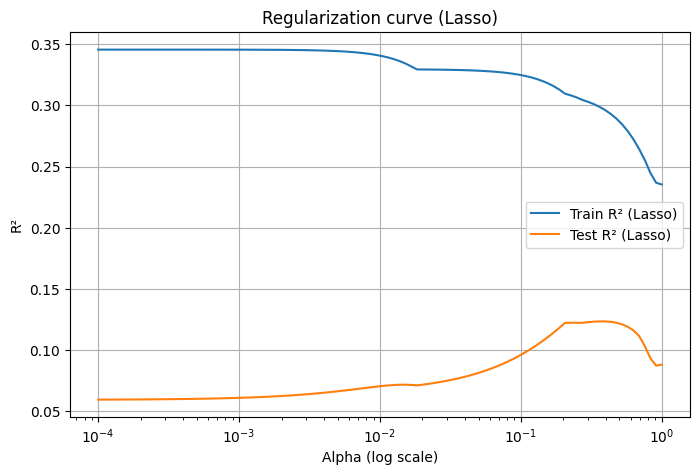

In [16]:
alphas = np.logspace(-4, 0, 100)
train_r2_lasso = []
test_r2_lasso = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000).fit(X_train, y_train)
    train_r2_lasso.append(lasso.score(X_train, y_train))
    test_r2_lasso.append(lasso.score(X_test, y_test))

plt.figure(figsize=(8,5))
plt.semilogx(alphas, train_r2_lasso, label='Train R² (Lasso)')
plt.semilogx(alphas, test_r2_lasso, label='Test R² (Lasso)')
plt.xlabel('Alpha (log scale)')
plt.ylabel('R²')
plt.title('Regularization curve (Lasso)')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
df = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv', nrows=200)
y = df['Outcome']
X = df.drop('Outcome', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

print(f"Train accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Train F1: {f1_score(y_train, y_train_pred):.4f}")
print(f"Test F1: {f1_score(y_test, y_test_pred):.4f}")

Train accuracy: 1.0000
Test accuracy: 0.5500
Train F1: 1.0000
Test F1: 0.5263


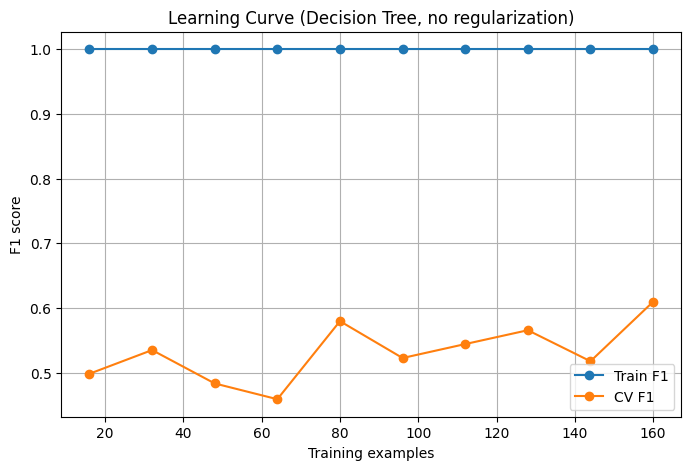

In [18]:
train_sizes_abs, train_scores, test_scores = learning_curve(
    DecisionTreeClassifier(random_state=1), X, y, 
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='f1', n_jobs=-1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes_abs, np.mean(train_scores, axis=1), 'o-', label='Train F1')
plt.plot(train_sizes_abs, np.mean(test_scores, axis=1), 'o-', label='CV F1')
plt.xlabel('Training examples')
plt.ylabel('F1 score')
plt.title('Learning Curve (Decision Tree, no regularization)')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
tree_reg = DecisionTreeClassifier(random_state=1, max_depth=4).fit(X_train, y_train)
print(f"Train accuracy: {accuracy_score(y_train, tree_reg.predict(X_train)):.4f}")
print(f"Test accuracy: {accuracy_score(y_test, tree_reg.predict(X_test)):.4f}")

Train accuracy: 0.8500
Test accuracy: 0.6250


In [20]:
df_full = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv')
y_full = df_full['Outcome']
X_full = df_full.drop('Outcome', axis=1)

X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
tree_full = DecisionTreeClassifier(random_state=1).fit(X_tr, y_tr)
print(f"Train accuracy (full data): {accuracy_score(y_tr, tree_full.predict(X_tr)):.4f}")
print(f"Test accuracy (full data): {accuracy_score(y_te, tree_full.predict(X_te)):.4f}")

Train accuracy (full data): 1.0000
Test accuracy (full data): 0.7273


In [21]:
data = fetch_openml(name='delta_ailerons', parser='auto')
X = pd.get_dummies(data.data)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

log_reg = LogisticRegression(max_iter=1000).fit(X_train, y_train)
print(f"Train accuracy: {log_reg.score(X_train, y_train):.4f}")
print(f"Test accuracy: {log_reg.score(X_test, y_test):.4f}")

Train accuracy: 0.6092
Test accuracy: 0.5989


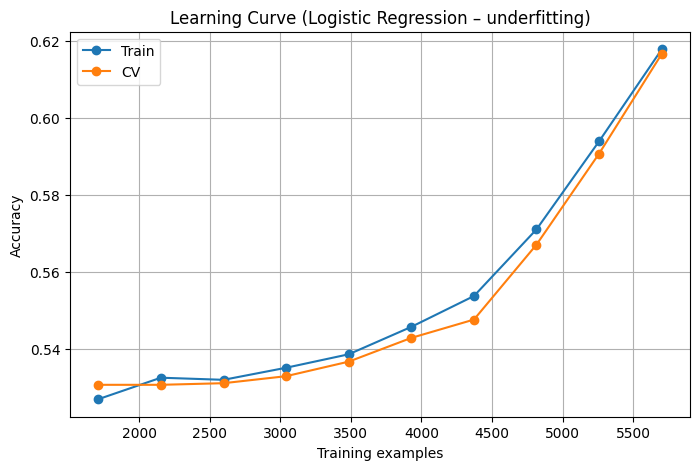

In [22]:
train_sizes_abs, train_scores, test_scores = learning_curve(
    LogisticRegression(max_iter=1000), X, y, 
    train_sizes=np.linspace(0.3, 1.0, 10), cv=5, scoring='accuracy', n_jobs=-1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes_abs, np.mean(train_scores, axis=1), 'o-', label='Train')
plt.plot(train_sizes_abs, np.mean(test_scores, axis=1), 'o-', label='CV')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve (Logistic Regression – underfitting)')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
mlp = MLPClassifier(max_iter=1000, random_state=42).fit(X_train, y_train)
print(f"MLP Train accuracy: {mlp.score(X_train, y_train):.4f}")
print(f"MLP Test accuracy: {mlp.score(X_test, y_test):.4f}")

MLP Train accuracy: 0.9390
MLP Test accuracy: 0.9397


In [24]:
poly = PolynomialFeatures(2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

ridge_poly = RidgeClassifier(alpha=0.001).fit(X_train_poly, y_train)
print(f"Poly+Ridge train accuracy: {ridge_poly.score(X_train_poly, y_train):.4f}")
print(f"Poly+Ridge test accuracy: {ridge_poly.score(X_test_poly, y_test):.4f}")

Poly+Ridge train accuracy: 0.9392
Poly+Ridge test accuracy: 0.9362


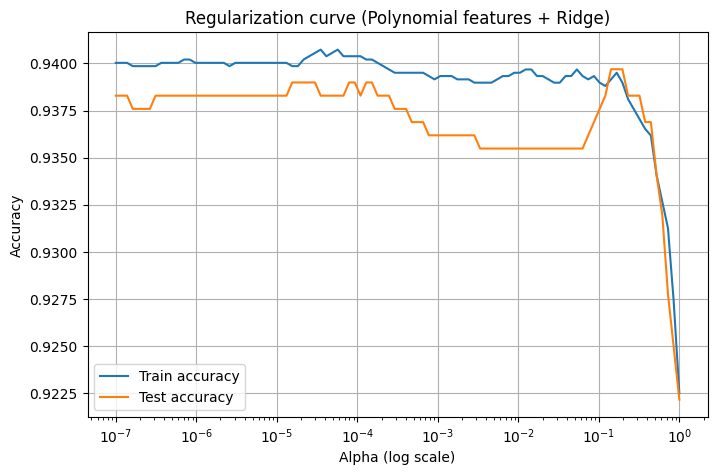

In [25]:
alphas = np.logspace(-7, 0, 100)
train_scores_poly = []
test_scores_poly = []

for a in alphas:
    ridge = RidgeClassifier(alpha=a).fit(X_train_poly, y_train)
    train_scores_poly.append(ridge.score(X_train_poly, y_train))
    test_scores_poly.append(ridge.score(X_test_poly, y_test))

plt.figure(figsize=(8,5))
plt.semilogx(alphas, train_scores_poly, label='Train accuracy')
plt.semilogx(alphas, test_scores_poly, label='Test accuracy')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Accuracy')
plt.title('Regularization curve (Polynomial features + Ridge)')
plt.legend()
plt.grid(True)
plt.show()

# Задания для самостоятельного решения

## Задание 1. Классификация: precision, recall, F1

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import learning_curve
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=10000, n_features=500,
                           n_informative=50, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=3)

for name, clf in [('LogReg', LogisticRegression(max_iter=1000)),
                  ('Ridge(under)', RidgeClassifier(alpha=1e6)),
                  ('Ridge(opt)', RidgeClassifier(alpha=26500))]:
    clf.fit(X_train, y_train)
    for split, Xs, ys in [('train', X_train, y_train), ('test', X_test, y_test)]:
        p = precision_score(ys, clf.predict(Xs))
        r = recall_score(ys, clf.predict(Xs))
        f = f1_score(ys, clf.predict(Xs))
        print(f'{name} {split}: precision={p:.3f} recall={r:.3f} f1={f:.3f}')


In [ ]:
# Кривые обучения для переобученной (LogReg) и недообученной (Ridge alpha=1e6) моделей
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, clf), scoring in zip(axes,
    [('LogReg', LogisticRegression(max_iter=1000)), ('Ridge(under)', RidgeClassifier(alpha=1e6))],
    ['f1', 'f1']):
    ts, tr, te = learning_curve(clf, X, y, cv=5, scoring=scoring,
                                train_sizes=np.linspace(0.1,1,10), n_jobs=-1)
    ax.plot(ts, tr.mean(1), 'o-', label='Train F1')
    ax.plot(ts, te.mean(1), 'o-', label='CV F1')
    ax.set_title(f'Learning curve: {name}')
    ax.set_xlabel('Samples'); ax.set_ylabel('F1')
    ax.legend(); ax.grid()
plt.tight_layout(); plt.show()
# Вывод: у LogReg train>test — переобучение; у Ridge(alpha=1e6) обе кривые низкие — недообучение


## Задание 2. Регрессия: SVM, KNN, Decision Tree

In [ ]:
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0)

# --- SVR: влияние C ---
Cs = [0.01, 0.1, 1, 10, 100]
tr_r2, te_r2 = [], []
for C in Cs:
    m = SVR(C=C).fit(X_tr, y_tr)
    tr_r2.append(m.score(X_tr, y_tr))
    te_r2.append(m.score(X_te, y_te))
plt.figure(figsize=(7,4))
plt.semilogx(Cs, tr_r2, 'o-', label='Train'); plt.semilogx(Cs, te_r2, 'o-', label='Test')
plt.xlabel('C'); plt.ylabel('R²'); plt.title('SVR: влияние C')
plt.legend(); plt.grid(); plt.show()
# Малый C — недообучение, большой C — переобучение


In [ ]:
# --- KNN: влияние числа соседей ---
ks = [1, 3, 5, 10, 20, 50]
tr_r2, te_r2 = [], []
for k in ks:
    m = KNeighborsRegressor(n_neighbors=k).fit(X_tr, y_tr)
    tr_r2.append(m.score(X_tr, y_tr))
    te_r2.append(m.score(X_te, y_te))
plt.figure(figsize=(7,4))
plt.plot(ks, tr_r2, 'o-', label='Train'); plt.plot(ks, te_r2, 'o-', label='Test')
plt.xlabel('n_neighbors'); plt.ylabel('R²'); plt.title('KNN: влияние числа соседей')
plt.legend(); plt.grid(); plt.show()
# k=1 — переобучение (train=1), большие k — недообучение


In [ ]:
# --- Decision Tree: max_depth ---
depths = range(1, 15)
tr_r2, te_r2 = [], []
for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=1).fit(X_tr, y_tr)
    tr_r2.append(m.score(X_tr, y_tr))
    te_r2.append(m.score(X_te, y_te))
plt.figure(figsize=(7,4))
plt.plot(list(depths), tr_r2, 'o-', label='Train'); plt.plot(list(depths), te_r2, 'o-', label='Test')
plt.xlabel('max_depth'); plt.ylabel('R²'); plt.title('DecisionTree: влияние max_depth')
plt.legend(); plt.grid(); plt.show()
best_d = list(depths)[te_r2.index(max(te_r2))]
print(f'Лучшая глубина: {best_d}, Test R²: {max(te_r2):.4f}')


## Задание 3. Lasso: кривые обучения, оптимальный alpha

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import learning_curve

# Регуляризационная кривая
alphas = np.logspace(-4, 0, 60)
tr_r2, te_r2 = [], []
for a in alphas:
    m = Lasso(alpha=a, max_iter=10000).fit(X_tr, y_tr)
    tr_r2.append(m.score(X_tr, y_tr)); te_r2.append(m.score(X_te, y_te))
best_a = alphas[np.argmax(te_r2)]
print(f'Оптимальный alpha: {best_a:.5f}, Test R²: {max(te_r2):.4f}')
plt.figure(figsize=(7,4))
plt.semilogx(alphas, tr_r2, label='Train'); plt.semilogx(alphas, te_r2, label='Test')
plt.axvline(best_a, color='r', linestyle='--', label=f'opt alpha={best_a:.4f}')
plt.xlabel('Alpha'); plt.ylabel('R²'); plt.title('Lasso: регуляризационная кривая')
plt.legend(); plt.grid(); plt.show()


In [ ]:
# Кривые обучения для трёх вариантов Lasso
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
configs = [('Переобучение', 1e-4), ('Недообучение', 1e-1), (f'Оптимум ({best_a:.4f})', best_a)]
for ax, (title, a) in zip(axes, configs):
    ts, tr, te = learning_curve(Lasso(alpha=a, max_iter=10000), X, y,
                                cv=5, scoring='r2', train_sizes=np.linspace(0.1,1,10), n_jobs=-1)
    ax.plot(ts, tr.mean(1), 'o-', label='Train'); ax.plot(ts, te.mean(1), 'o-', label='CV')
    ax.set_title(f'Lasso: {title}'); ax.set_xlabel('Samples'); ax.set_ylabel('R²')
    ax.legend(); ax.grid()
plt.tight_layout(); plt.show()


## Задание 4. ElasticNet: влияние двух параметров

In [ ]:
from sklearn.linear_model import ElasticNet

# Исследуем alpha и l1_ratio
alphas_en = np.logspace(-3, 0, 20)
l1_ratios = [0.1, 0.5, 0.9]

plt.figure(figsize=(8, 5))
for l1 in l1_ratios:
    tr_r2, te_r2 = [], []
    for a in alphas_en:
        m = ElasticNet(alpha=a, l1_ratio=l1, max_iter=10000).fit(X_tr, y_tr)
        te_r2.append(m.score(X_te, y_te))
    plt.semilogx(alphas_en, te_r2, 'o-', label=f'l1_ratio={l1}')
plt.xlabel('Alpha'); plt.ylabel('Test R²')
plt.title('ElasticNet: влияние alpha и l1_ratio')
plt.legend(); plt.grid(); plt.show()
# l1_ratio=0 → Ridge; l1_ratio=1 → Lasso


In [ ]:
# Лучшая комбинация параметров
best_score, best_params = -np.inf, {}
for a in alphas_en:
    for l1 in np.linspace(0.1, 1, 10):
        m = ElasticNet(alpha=a, l1_ratio=l1, max_iter=10000).fit(X_tr, y_tr)
        s = m.score(X_te, y_te)
        if s > best_score:
            best_score, best_params = s, {'alpha': a, 'l1_ratio': round(l1, 2)}
print(f'Лучший Test R²: {best_score:.4f}, params: {best_params}')


## Задание 5. Дерево решений (diabetes): оптимальная глубина, F1

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import learning_curve

df_full = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML4.3%20diagnostics/diabetes.csv')
y_full = df_full['Outcome']; X_full = df_full.drop('Outcome', axis=1)
X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# Кривая регуляризации по max_depth
depths = range(1, 20)
tr_f1, te_f1 = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=1).fit(X_tr, y_tr)
    tr_f1.append(f1_score(y_tr, m.predict(X_tr)))
    te_f1.append(f1_score(y_te, m.predict(X_te)))

best_d = list(depths)[te_f1.index(max(te_f1))]
print(f'Оптимальная глубина: {best_d}, Test F1: {max(te_f1):.4f}')

plt.figure(figsize=(8, 5))
plt.plot(list(depths), tr_f1, 'o-', label='Train F1')
plt.plot(list(depths), te_f1, 'o-', label='Test F1')
plt.axvline(best_d, color='r', linestyle='--', label=f'opt depth={best_d}')
plt.xlabel('max_depth'); plt.ylabel('F1'); plt.title('Diabetes: кривая регуляризации (F1)')
plt.legend(); plt.grid(); plt.show()


In [ ]:
# Кривая обучения для оптимальной модели (F1)
ts, tr, te = learning_curve(DecisionTreeClassifier(max_depth=best_d, random_state=1),
                            X_full, y_full, cv=5, scoring='f1',
                            train_sizes=np.linspace(0.1,1,10), n_jobs=-1)
plt.figure(figsize=(7,4))
plt.plot(ts, tr.mean(1), 'o-', label='Train F1'); plt.plot(ts, te.mean(1), 'o-', label='CV F1')
plt.xlabel('Samples'); plt.ylabel('F1')
plt.title(f'Кривая обучения: DecisionTree(max_depth={best_d})')
plt.legend(); plt.grid(); plt.show()

# Качество на всём датасете
opt_tree = DecisionTreeClassifier(max_depth=best_d, random_state=1).fit(X_full, y_full)
print(f'F1 на всём датасете: {f1_score(y_full, opt_tree.predict(X_full)):.4f}')


## Задание 6. Анализ на датасетах OpenML

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')

DATASETS = [
    'phoneme', 'banknote-authentication', 'mammography',
    'electricity', 'mozilla4', 'volcanoes-b3'
]
# delta_ailerons — регрессия, kropt/nursery — большие, обрабатываем отдельно

results = []
for name in DATASETS:
    try:
        d = fetch_openml(name=name, as_frame=True, parser='auto')
        X = pd.get_dummies(d.data)
        y = d.target
        if y.dtype == object:
            y = LabelEncoder().fit_transform(y)
        # Базовое дерево
        dt = DecisionTreeClassifier(random_state=1)
        f1_cv = cross_val_score(dt, X, y, cv=3, scoring='f1_weighted', n_jobs=-1).mean()
        # Регуляризованное дерево
        dt_reg = DecisionTreeClassifier(max_depth=5, random_state=1)
        f1_reg = cross_val_score(dt_reg, X, y, cv=3, scoring='f1_weighted', n_jobs=-1).mean()
        results.append({'dataset': name, 'f1_no_reg': round(f1_cv,4), 'f1_depth5': round(f1_reg,4)})
        print(f'{name}: full={f1_cv:.4f}, depth=5: {f1_reg:.4f}')
    except Exception as e:
        print(f'{name}: ошибка — {e}')

pd.DataFrame(results).set_index('dataset')


In [ ]:
# Регрессионный датасет delta_ailerons
d = fetch_openml(name='delta_ailerons', as_frame=True, parser='auto')
X_da = pd.get_dummies(d.data); y_da = d.target.astype(float)
X_tr_da, X_te_da, y_tr_da, y_te_da = train_test_split(X_da, y_da, test_size=0.2, random_state=0)

for C in [0.01, 0.1, 1, 10]:
    from sklearn.svm import SVR
    m = SVR(C=C).fit(X_tr_da, y_tr_da)
    print(f'delta_ailerons SVR C={C}: train={m.score(X_tr_da,y_tr_da):.3f} test={m.score(X_te_da,y_te_da):.3f}')


In [ ]:
# kropt и nursery — категориальные, большие → только accuracy через кросс-вал
for name in ['kropt', 'nursery']:
    try:
        d = fetch_openml(name=name, as_frame=True, parser='auto')
        X = pd.get_dummies(d.data)
        y = LabelEncoder().fit_transform(d.target)
        dt = DecisionTreeClassifier(max_depth=10, random_state=1)
        acc = cross_val_score(dt, X, y, cv=3, scoring='accuracy', n_jobs=-1).mean()
        print(f'{name}: accuracy(depth=10) = {acc:.4f}')
    except Exception as e:
        print(f'{name}: {e}')
